# Loan Approval Prediction — End-to-End Banking Classification

## Project Overview

This notebook builds an **end-to-end machine learning classification project** for a banking use case:

> **Predict whether a loan application should be approved or not approved based on applicant, income, credit, debt, employment, and property information.**

The notebook is designed as an educational but realistic banking analytics project. It covers:

1. Business understanding
2. Dataset understanding
3. Data quality checks
4. Exploratory Data Analysis (EDA)
5. Feature engineering
6. Train/test split
7. Preprocessing pipelines
8. Baseline Logistic Regression
9. Random Forest
10. Model comparison
11. Threshold analysis
12. Confusion matrix and ROC-AUC
13. Feature importance
14. Customer-level approval scoring
15. Business interpretation
16. Model limitations and next steps

> **Important:** The dataset is synthetic and intended for learning. It is not suitable for real credit decisions.

## 1. Business Understanding

### Business Problem

A bank receives many loan applications. Manual assessment can be time-consuming and inconsistent, while a fully automated decision can create credit, regulatory, and customer-experience risks.

The objective of this project is to build a model that estimates the probability that an application belongs to the **approved** class.

### Business Objective

Use the model as a **decision-support / pre-screening tool** to:

- prioritize applications for review,
- identify applications that are likely to qualify,
- identify applications that require additional assessment,
- improve consistency in the initial screening process.

### Target Variable

`Loan_Status`

- `1` = Approved
- `0` = Not Approved

### Important banking perspective

The model should **not automatically replace credit policy**. In a real bank, approval would also depend on policy rules, regulatory requirements, affordability checks, collateral, fraud checks, document verification, and human/credit committee review.

## 2. Project Questions

We will answer questions such as:

1. Which variables are associated with loan approval?
2. How important is credit history?
3. Does debt burden affect approval probability?
4. Which classification algorithm performs better?
5. What happens when we change the probability threshold?
6. How many false approvals and false rejections occur?
7. How can the model output be translated into a practical loan-review workflow?

## 3. Dataset Description

The synthetic dataset contains 5,000 loan applications.

### Main variables

| Variable | Description |
|---|---|
| `Loan_ID` | Application identifier |
| `Age` | Applicant age |
| `Gender` | Applicant gender |
| `Married` | Marital status |
| `Dependents` | Number of dependents |
| `Education` | Education level |
| `Self_Employed` | Self-employed status |
| `Annual_Income` | Applicant annual income |
| `Coapplicant_Income` | Co-applicant annual income |
| `Credit_History` | Simplified credit-history indicator |
| `Loan_Amount` | Requested loan amount |
| `Loan_Term_Months` | Requested loan term |
| `Property_Area` | Property location category |
| `Existing_Loans` | Number of existing loans |
| `Monthly_Debt_Payment` | Existing monthly debt payment |
| `Employment_Years` | Years of employment |
| `Loan_Status` | Target: 1 approved, 0 not approved |

### Derived variables

Later we will create:

- `Total_Income`
- `Estimated_EMI`
- `DTI` — Debt-to-Income ratio

## 4. Why This Is a Classification Problem

The target contains two classes:

```text
0 → Not Approved
1 → Approved
```

Therefore, this is a **binary classification** problem.

The model can produce both:

- a class prediction, and
- a probability.

For example:

```text
Application A
P(Approved) = 0.92 → likely approve

Application B
P(Approved) = 0.47 → borderline

Application C
P(Approved) = 0.08 → likely not approve
```

The probability is often more useful for banking workflows than a simple yes/no output because the threshold can be adjusted according to business objectives.

## 5. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling, scikit-learn for preprocessing, modeling and metrics, and Matplotlib/Seaborn for visualisation — and silences non-critical warnings so the output stays readable.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import sklearn

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## 6. Load the Sample Data

The CSV file generated for this project is located next to this notebook.

If you are running the notebook in another folder, change the path below.

In [2]:
DATA_PATH = Path("bank_loan_approval_sample.csv")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()

Rows: 5,000
Columns: 17


,Loan_ID,Age,Gender,Married,Dependents,Education,Self_Employed,Annual_Income,Coapplicant_Income,Credit_History,Loan_Amount,Loan_Term_Months,Property_Area,Existing_Loans,Monthly_Debt_Payment,Employment_Years,Loan_Status
0,LN00001,25,Male,Yes,2,Graduate,No,197200000.0,11500000.0,0.0,227000000.0,60.0,Urban,1,3530000.0,2.4,1
1,LN00002,55,Female,No,0,Not Graduate,No,154200000.0,37200000.0,0.0,193000000.0,24.0,Urban,0,920000.0,17.0,1
2,LN00003,50,Female,Yes,0,Graduate,Yes,279200000.0,102900000.0,1.0,820000000.0,48.0,Urban,1,1540000.0,18.0,0
3,LN00004,40,Female,Yes,3+,Graduate,No,159100000.0,76500000.0,1.0,194000000.0,60.0,Rural,2,3490000.0,24.7,1
4,LN00005,40,Male,Yes,1,Graduate,No,284600000.0,110400000.0,0.0,345000000.0,24.0,Urban,1,2580000.0,5.5,1


### Initial observation

Before modeling, always understand:

- how many observations exist,
- which fields are numeric or categorical,
- whether the target exists,
- whether there are missing values,
- whether there are suspicious values or leakage.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Loan_ID               5000 non-null   str    
 1   Age                   5000 non-null   int64  
 2   Gender                4900 non-null   str    
 3   Married               5000 non-null   str    
 4   Dependents            5000 non-null   str    
 5   Education             5000 non-null   str    
 6   Self_Employed         4850 non-null   str    
 7   Annual_Income         5000 non-null   float64
 8   Coapplicant_Income    5000 non-null   float64
 9   Credit_History        4850 non-null   float64
 10  Loan_Amount           4900 non-null   float64
 11  Loan_Term_Months      4900 non-null   float64
 12  Property_Area         5000 non-null   str    
 13  Existing_Loans        5000 non-null   int64  
 14  Monthly_Debt_Payment  4875 non-null   float64
 15  Employment_Years      5000 non-n

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,5000,5000,LN00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,5000.0,NaN,NaN,NaN,42.9414,13.020855,21.0,32.0,43.0,54.0,65.0
Gender,4900,2,Male,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,5000,2,Yes,3067,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,5000,4,0,2363,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,5000,2,Graduate,3523,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,4850,2,No,4173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Annual_Income,5000.0,NaN,NaN,NaN,139626180.0,83383536.717068,11500000.0,82400000.0,120200000.0,173825000.0,909500000.0
Coapplicant_Income,5000.0,NaN,NaN,NaN,48746020.0,47962634.946694,2300000.0,20400000.0,34900000.0,60200000.0,921200000.0
Credit_History,4850.0,NaN,NaN,NaN,0.836082,0.370239,0.0,1.0,1.0,1.0,1.0


## 7. Data Quality Check

We check:

1. Duplicate applications
2. Missing values
3. Unique values
4. Target distribution
5. Potential invalid values

In [5]:
print("Duplicate rows:", df.duplicated().sum())

missing = (
    df.isna()
      .sum()
      .to_frame("Missing_Count")
      .assign(Missing_Pct=lambda x: x["Missing_Count"] / len(df) * 100)
      .sort_values("Missing_Pct", ascending=False)
)

missing[missing["Missing_Count"] > 0]

Duplicate rows: 0


,Missing_Count,Missing_Pct
Self_Employed,150,3.0
Credit_History,150,3.0
Monthly_Debt_Payment,125,2.5
Loan_Amount,100,2.0
Gender,100,2.0
Loan_Term_Months,100,2.0


In [6]:
print("Unique Loan IDs:", df["Loan_ID"].nunique())
print("Total rows:", len(df))

Unique Loan IDs: 5000
Total rows: 5000


### Data type fix — `Dependents` is stored as text

`Dependents` looks numeric, but the raw file stores it as **text** because the largest category is written as `3+`:

```text
0, 1, 2, 3+
```

`3+` means "three or more" and is the highest value of this variable, so it must become `3` before modeling.

If we skip this step, two things go wrong:

1. pandas keeps the whole column as text, not as numbers.
2. `SimpleImputer(strategy="median")` accepts numeric data only, so the preprocessing pipeline fails with:

```text
ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: '3+'
```

We therefore clean the column once, here in the data quality stage, so that every later step (EDA, feature engineering, imputation, scaling) sees a proper numeric variable.

```python
df["Dependents"] = (
    df["Dependents"]
      .astype("string")
      .str.strip()
      .str.replace("+", "", regex=False)
)

df["Dependents"] = pd.to_numeric(df["Dependents"], errors="coerce")
```

Notes:

- `errors="coerce"` turns any unexpected text into `NaN` instead of crashing, so the median imputer can handle it later.
- The ordering of the categories is preserved (`0 < 1 < 2 < 3`), which is what we want for a count-like variable.

In [7]:
print("Before cleaning:", df["Dependents"].dtype)
print("Raw values     :", sorted(df["Dependents"].unique()))

# "3+" means "three or more", the highest category of this variable.
df["Dependents"] = (
    df["Dependents"]
      .astype("string")
      .str.strip()
      .str.replace("+", "", regex=False)
)

# Any unparsable text becomes NaN so the median imputer can handle it.
df["Dependents"] = pd.to_numeric(df["Dependents"], errors="coerce")

print("\nAfter cleaning :", df["Dependents"].dtype)
print("Numeric values :", sorted(df["Dependents"].dropna().unique()))
print("Unparsable rows:", int(df["Dependents"].isna().sum()))

Before cleaning: str
Raw values     : ['0', '1', '2', '3+']

After cleaning : Int64
Numeric values : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Unparsable rows: 0


## 8. Target Distribution

Class balance matters because accuracy can be misleading when one class dominates.

In [8]:
target_counts = df["Loan_Status"].value_counts().sort_index()

target_pct = (
    df["Loan_Status"]
      .value_counts(normalize=True)
      .sort_index()
      .mul(100)
)

pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_pct.round(2)
})

,Count,Percentage
Loan_Status,,
0,2546,50.92
1,2454,49.08


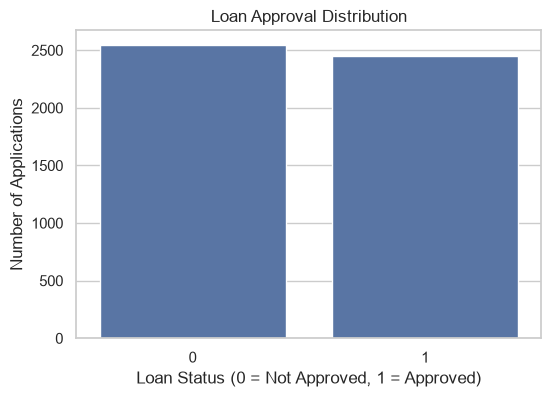

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Loan_Status")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status (0 = Not Approved, 1 = Approved)")
plt.ylabel("Number of Applications")
plt.show()

## 9. Exploratory Data Analysis — Credit History

Credit history is expected to be one of the strongest variables in this educational dataset.

We compare approval rates across credit-history groups.

In [10]:
credit_approval = (
    df.groupby("Credit_History", dropna=False)["Loan_Status"]
      .agg(["count", "mean"])
      .rename(columns={"mean": "Approval_Rate"})
)

credit_approval["Approval_Rate"] *= 100
credit_approval

,count,Approval_Rate
Credit_History,,
0.0,795,14.213836
1.0,4055,55.906289
NaN,150,49.333333


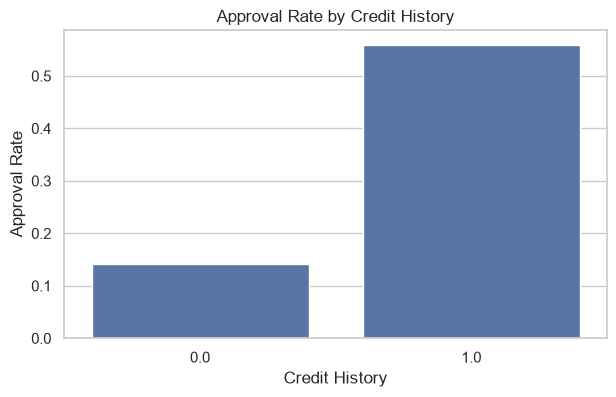

In [11]:
plt.figure(figsize=(7, 4))
sns.barplot(
    data=df,
    x="Credit_History",
    y="Loan_Status",
    errorbar=None
)
plt.title("Approval Rate by Credit History")
plt.ylabel("Approval Rate")
plt.xlabel("Credit History")
plt.show()

## 10. EDA — Income and Loan Amount

A useful banking question is whether requested loan size is reasonable relative to income.

We inspect the distributions and compare approved versus non-approved applications.

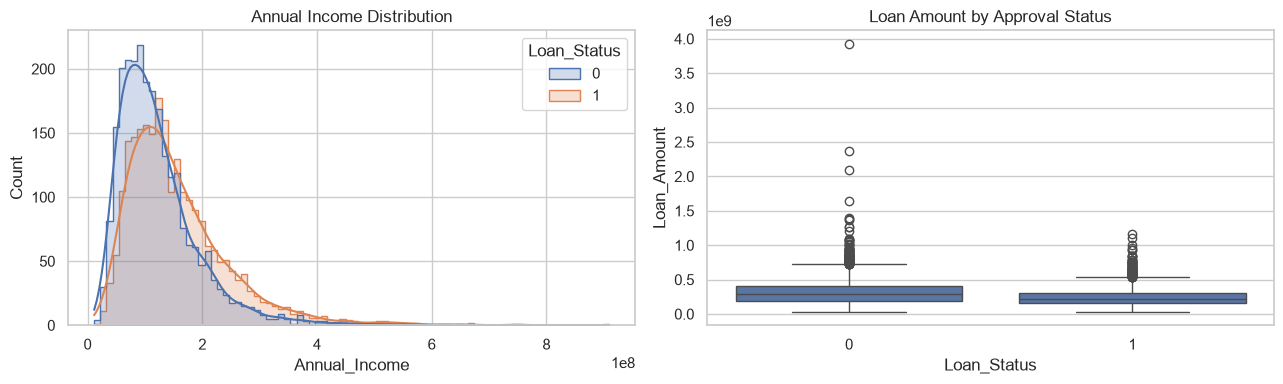

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(
    data=df,
    x="Annual_Income",
    hue="Loan_Status",
    kde=True,
    element="step",
    ax=axes[0]
)
axes[0].set_title("Annual Income Distribution")

sns.boxplot(
    data=df,
    x="Loan_Status",
    y="Loan_Amount",
    ax=axes[1]
)
axes[1].set_title("Loan Amount by Approval Status")

plt.tight_layout()
plt.show()

## 11. EDA — Existing Debt

Applicants with a higher existing debt burden may have a lower capacity to take additional debt.

This motivates a later feature-engineering step: **DTI (Debt-to-Income ratio)**.

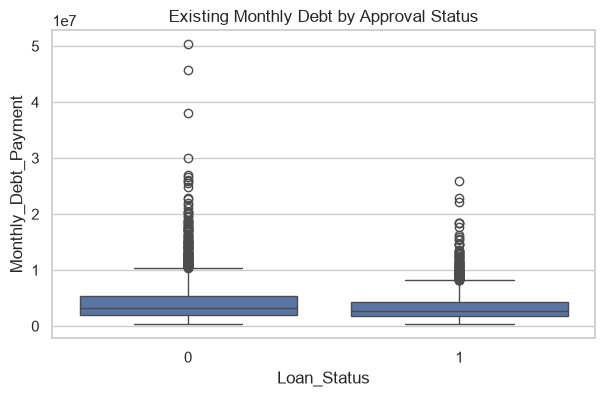

In [13]:
plt.figure(figsize=(7, 4))
sns.boxplot(
    data=df,
    x="Loan_Status",
    y="Monthly_Debt_Payment"
)
plt.title("Existing Monthly Debt by Approval Status")
plt.show()

## 12. Feature Engineering

We create banking-oriented variables.

### Total Income

```text
Total Income = Applicant Income + Co-applicant Income
```

### Estimated EMI

For educational purposes, we use the standard installment formula:

```text
EMI = P × r × (1+r)^n / ((1+r)^n - 1)
```

where:

- `P` = loan amount
- `r` = monthly interest rate
- `n` = loan term in months

We assume a simplified annual interest rate of 10%.

### DTI

```text
DTI = (Existing Monthly Debt + Estimated EMI) / Monthly Income
```

DTI provides a simple proxy for repayment burden.

In [ ]:
annual_rate = 0.10
monthly_rate = annual_rate / 12

# Defaults for missing raw fields. They are captured once from the training
# data and must be reused at scoring time, never recomputed on a new batch.
FEATURE_DEFAULTS = {
    "Loan_Term_Months": float(df["Loan_Term_Months"].median()),
    "Loan_Amount": float(df["Loan_Amount"].median()),
    "Monthly_Debt_Payment": float(df["Monthly_Debt_Payment"].median())
}


def add_engineered_features(data, defaults=FEATURE_DEFAULTS,
                            monthly_rate=monthly_rate):
    """Create Total_Income, Estimated_EMI, Monthly_Income and DTI.

    The same function is used for training and for scoring new applicants, so
    both paths always produce exactly the same columns.
    """
    data = data.copy()

    data["Total_Income"] = (
        data["Annual_Income"].fillna(0)
        + data["Coapplicant_Income"].fillna(0)
    )

    term = data["Loan_Term_Months"].fillna(defaults["Loan_Term_Months"])
    loan_amount = data["Loan_Amount"].fillna(defaults["Loan_Amount"])

    data["Estimated_EMI"] = (
        loan_amount * monthly_rate * (1 + monthly_rate) ** term
        / ((1 + monthly_rate) ** term - 1)
    )

    data["Monthly_Income"] = data["Total_Income"] / 12

    data["DTI"] = (
        data["Monthly_Debt_Payment"].fillna(defaults["Monthly_Debt_Payment"])
        + data["Estimated_EMI"]
    ) / data["Monthly_Income"].replace(0, np.nan)

    return data


df = add_engineered_features(df)

df[[
    "Annual_Income",
    "Coapplicant_Income",
    "Total_Income",
    "Loan_Amount",
    "Estimated_EMI",
    "Monthly_Debt_Payment",
    "DTI",
    "Loan_Status"
]].head()

### DTI interpretation

A higher DTI generally means a larger portion of monthly income is committed to debt.

For illustration:

```text
DTI = 0.25 → approximately 25% of monthly income goes to debt
DTI = 0.60 → approximately 60% goes to debt
```

This is an educational proxy. Real banks use policy-specific affordability calculations and verified income/debt information.

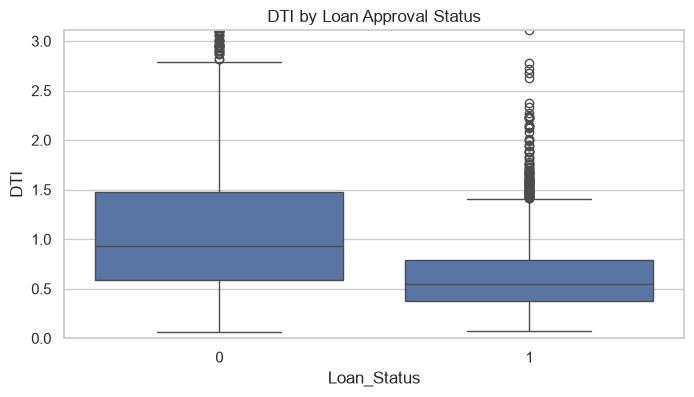

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x="Loan_Status",
    y="DTI"
)
plt.ylim(0, df["DTI"].quantile(0.98))
plt.title("DTI by Loan Approval Status")
plt.show()

## 13. Prepare Modeling Dataset

We remove the identifier and target from the feature matrix.

We intentionally keep the raw variables and let the preprocessing pipeline handle missing values and categorical encoding.

This reduces the risk of inconsistent preprocessing between training and scoring.

In [16]:
X = df.drop(columns=["Loan_ID", "Loan_Status"])
y = df["Loan_Status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 19)
y shape: (5000,)


## 14. Train-Test Split

We use an 80/20 split.

`stratify=y` keeps the approval-rate distribution approximately consistent between train and test data.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training: (4000, 19)
Testing : (1000, 19)

Train target distribution:
Loan_Status
0    0.509
1    0.491
Name: proportion, dtype: float64

Test target distribution:
Loan_Status
0    0.509
1    0.491
Name: proportion, dtype: float64


## 15. Identify Numeric and Categorical Features

The preprocessing strategy is:

### Numeric
- Missing values → median
- Scaling → StandardScaler

### Categorical
- Missing values → most frequent
- Encoding → OneHotEncoder

Using a pipeline is important because exactly the same transformations are applied during training and future scoring.

In [18]:
numeric_features = [
    "Age",
    "Dependents",
    "Annual_Income",
    "Coapplicant_Income",
    "Credit_History",
    "Loan_Amount",
    "Loan_Term_Months",
    "Existing_Loans",
    "Monthly_Debt_Payment",
    "Employment_Years",
    "Total_Income",
    "Estimated_EMI",
    "Monthly_Income",
    "DTI"
]

categorical_features = [
    "Gender",
    "Married",
    "Education",
    "Self_Employed",
    "Property_Area"
]

In [19]:
# Guard rail: every column declared as numeric must really be numeric.
# If a text column slips into this list, the pipeline raises:
# ValueError: Cannot use median strategy with non-numeric data
non_numeric_features = [
    col for col in numeric_features
    if not pd.api.types.is_numeric_dtype(df[col])
]

print("Columns declared numeric but stored as text:", non_numeric_features)

missing_numeric = df[numeric_features].isna().sum()
print("\nNumeric columns with missing values:")
print(missing_numeric[missing_numeric > 0])

assert not non_numeric_features, (
    f"These columns must be converted to numeric before modeling: "
    f"{non_numeric_features}"
)

Columns declared numeric but stored as text: []

Numeric columns with missing values:
Credit_History          150
Loan_Amount             100
Loan_Term_Months        100
Monthly_Debt_Payment    125
dtype: int64


In [20]:
# Safety net: some raw columns are text-encoded numbers (for example Dependents "3+")
# and SimpleImputer(strategy="median") accepts numeric data only.
# Coercing inside the pipeline keeps training and scoring types identical.
def coerce_text_numbers(X):
    """Convert text-encoded numbers such as "3+" into plain floats."""
    X = pd.DataFrame(X).copy()
    for column in X.columns:
        X[column] = pd.to_numeric(
            X[column].astype("string").str.replace("+", "", regex=False),
            errors="coerce"
        ).astype("float64")
    return X


numeric_pipeline = Pipeline(steps=[
    ("numeric_cleanup", FunctionTransformer(
        coerce_text_numbers,
        feature_names_out="one-to-one"
    )),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

## 16. Model 1 — Logistic Regression

Logistic Regression is a strong baseline for binary classification.

Advantages in banking:

- relatively simple,
- fast,
- probability-oriented,
- easier to explain than many complex models,
- useful as a benchmark.

We use `class_weight="balanced"` as a safeguard against class imbalance.

In [21]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

log_pred = logistic_model.predict(X_test)
log_prob = logistic_model.predict_proba(X_test)[:, 1]

## 17. Model 2 — Random Forest

Random Forest can capture nonlinear relationships and interactions.

It is useful as a comparison against the linear Logistic Regression baseline.

In [22]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

## 18. Evaluation Function

We calculate:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

### Why these metrics matter

**Accuracy** — overall proportion of correct predictions.

**Precision** — among applications predicted as approved, how many are actually approved.

**Recall** — among actually approved applications, how many the model identifies.

**F1** — balance between precision and recall.

**ROC-AUC** — ranking/discrimination quality across thresholds.

For real lending decisions, the appropriate metric depends on the business cost of false approvals versus false rejections.

In [23]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return pd.Series({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    })

results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, log_pred, log_prob),
    evaluate_model("Random Forest", y_test, rf_pred, rf_prob)
])

results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.744,0.7087,0.8126,0.7571,0.8251
1,Random Forest,0.743,0.7060,0.8167,0.7573,0.8087


## 19. Classification Reports

The classification report shows precision, recall and F1-score for each approval decision. In an imbalanced lending problem these per-class metrics matter more than raw accuracy, because missing a future defaulter (false negative) is usually far more costly than rejecting a good customer.


In [24]:
print("LOGISTIC REGRESSION")
print(classification_report(
    y_test,
    log_pred,
    target_names=["Not Approved", "Approved"],
    zero_division=0
))

print("\nRANDOM FOREST")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Not Approved", "Approved"],
    zero_division=0
))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

Not Approved       0.79      0.68      0.73       509
    Approved       0.71      0.81      0.76       491

    accuracy                           0.74      1000
   macro avg       0.75      0.75      0.74      1000
weighted avg       0.75      0.74      0.74      1000


RANDOM FOREST
              precision    recall  f1-score   support

Not Approved       0.79      0.67      0.73       509
    Approved       0.71      0.82      0.76       491

    accuracy                           0.74      1000
   macro avg       0.75      0.74      0.74      1000
weighted avg       0.75      0.74      0.74      1000



## 20. Confusion Matrix

The confusion matrix gives four outcomes:

| Actual | Predicted | Meaning |
|---|---|---|
| 0 | 0 | Correctly rejected |
| 0 | 1 | False approval |
| 1 | 0 | False rejection |
| 1 | 1 | Correctly approved |

In credit decisioning, these errors have different business consequences.

A false approval can create credit risk, while a false rejection can create lost business and customer dissatisfaction.

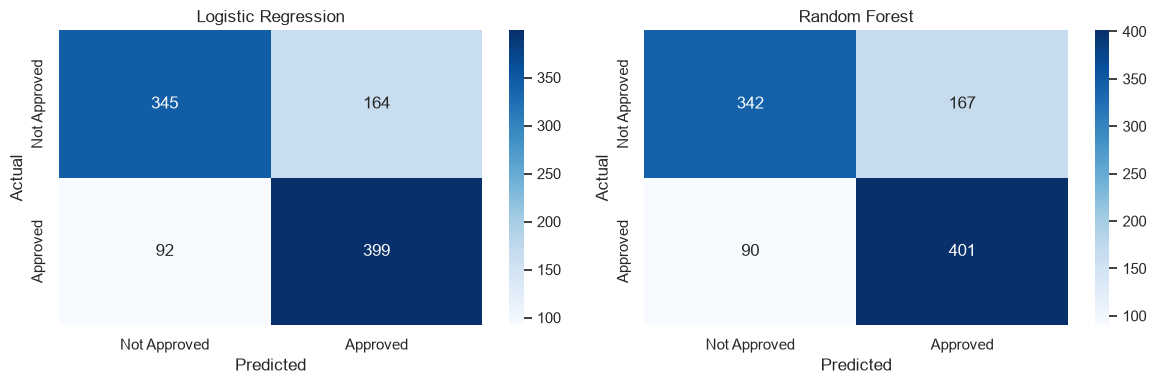

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, title in [
    (axes[0], log_pred, "Logistic Regression"),
    (axes[1], rf_pred, "Random Forest")
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Not Approved", "Approved"],
        yticklabels=["Not Approved", "Approved"]
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 21. ROC Curve Comparison

ROC curves plot true-positive rate against false-positive rate for both models across every threshold, and the AUC summarises how well each model ranks good applicants above bad ones regardless of the cutoff chosen.


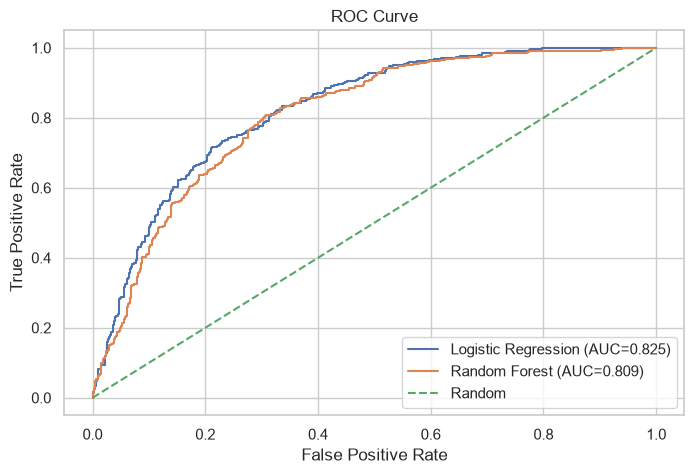

In [26]:
plt.figure(figsize=(8, 5))

for name, y_prob in [
    ("Logistic Regression", log_prob),
    ("Random Forest", rf_prob)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 22. Cross-Validation

A single train/test split can be sensitive to random sampling.

We use stratified 5-fold cross-validation to check whether the model's ROC-AUC is reasonably stable.

In [27]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Fold ROC-AUC:", np.round(cv_scores, 4))
print("Mean ROC-AUC:", round(cv_scores.mean(), 4))
print("Std ROC-AUC :", round(cv_scores.std(), 4))

Fold ROC-AUC: [0.776  0.7932 0.7845 0.7736 0.7893]
Mean ROC-AUC: 0.7833
Std ROC-AUC : 0.0075


## 23. Threshold Analysis

Most classifiers use 0.50 as the default probability threshold.

But in banking, 0.50 is not automatically the best business threshold.

For example:

```text
Threshold 0.30
→ more applications predicted as approved
→ potentially higher recall
→ potentially more false approvals

Threshold 0.70
→ fewer applications predicted as approved
→ potentially higher precision
→ potentially more false rejections
```

We inspect precision and recall across thresholds.

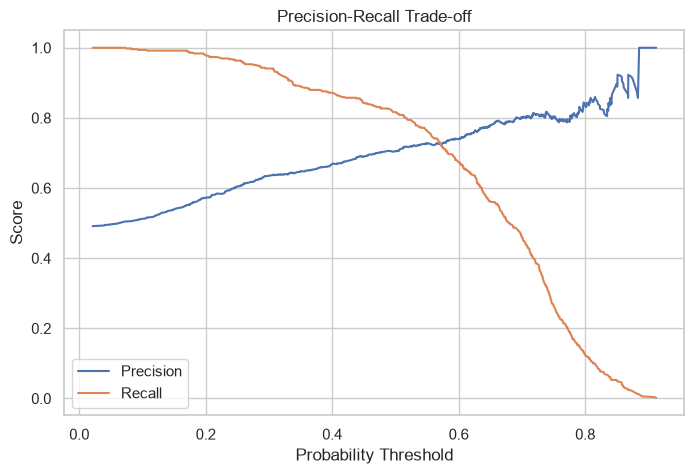

In [28]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    rf_prob
)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off")
plt.legend()
plt.show()

## 24. Choose a Business Threshold

For demonstration, we calculate metrics at several thresholds.

In a real bank, the threshold should be selected using:

- credit policy,
- expected loss,
- risk appetite,
- approval-rate targets,
- customer experience,
- operational capacity,
- regulatory requirements.

In [29]:
def threshold_metrics(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    return {
        "Threshold": threshold,
        "Approval_Rate_Predicted": pred.mean(),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
        "False_Approval_Count": ((y_true == 0) & (pred == 1)).sum(),
        "False_Rejection_Count": ((y_true == 1) & (pred == 0)).sum()
    }

threshold_table = pd.DataFrame([
    threshold_metrics(y_test, rf_prob, t)
    for t in [0.30, 0.40, 0.50, 0.60, 0.70]
])

threshold_table.round(4)

,Threshold,Approval_Rate_Predicted,Precision,Recall,F1,False_Approval_Count,False_Rejection_Count
0,0.3,0.727,0.6355,0.9409,0.7586,265,29
1,0.4,0.640,0.6688,0.8717,0.7569,212,63
2,0.5,0.568,0.7060,0.8167,0.7573,167,90
3,0.6,0.447,0.7405,0.6741,0.7058,116,160
4,0.7,0.281,0.8007,0.4582,0.5829,56,266


## 25. Feature Importance — Random Forest

Feature importance helps us understand which variables the model uses most strongly.

Important warning:

> Feature importance is not the same as causality.

A high importance score does not prove that changing that variable will cause an application to be approved.

In [30]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_estimator = rf_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_estimator.feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

importance_df.head(20)

,Feature,Importance
13,num__DTI,0.202884
4,num__Credit_History,0.159056
11,num__Estimated_EMI,0.084655
12,num__Monthly_Income,0.071664
5,num__Loan_Amount,0.069509
10,num__Total_Income,0.068120
2,num__Annual_Income,0.057587
8,num__Monthly_Debt_Payment,0.056002
3,num__Coapplicant_Income,0.046560
9,num__Employment_Years,0.043215


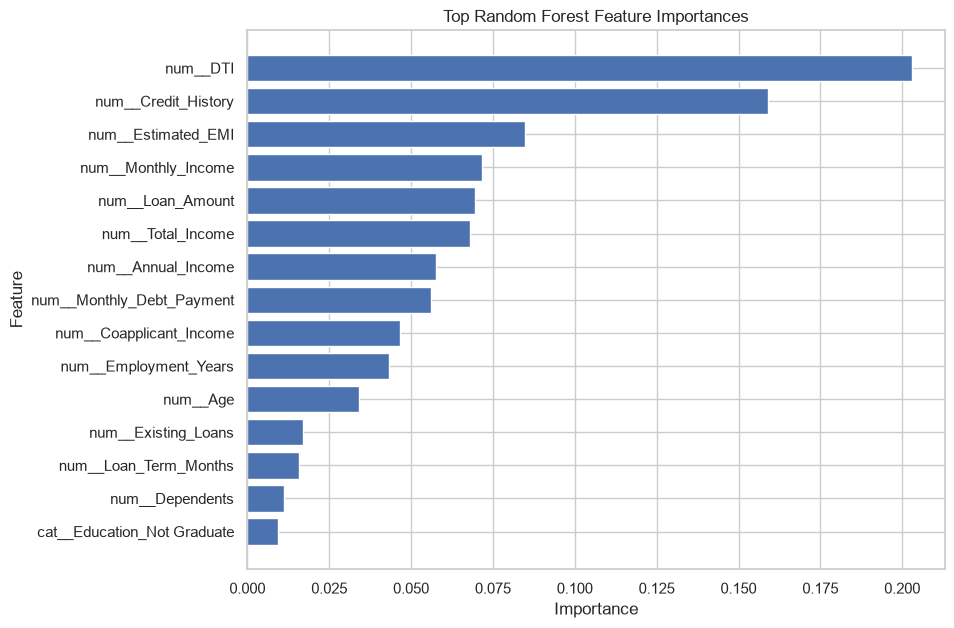

In [31]:
plt.figure(figsize=(9, 7))

top_features = importance_df.head(15).sort_values("Importance")

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 26. Customer-Level Loan Scoring

A useful model output is not only:

```text
Approved / Not Approved
```

but also:

```text
Probability of Approval
```

This allows applications to be segmented into operational categories.

In [32]:
scored = X_test.copy()

scored["Actual_Status"] = y_test.values
scored["Approval_Probability"] = rf_prob

scored["Decision_Segment"] = pd.cut(
    scored["Approval_Probability"],
    bins=[0, 0.30, 0.70, 1.0],
    labels=["Low Approval Probability", "Review", "High Approval Probability"],
    include_lowest=True
)

scored[
    [
        "Approval_Probability",
        "Decision_Segment",
        "Actual_Status"
    ]
].head(15)

,Approval_Probability,Decision_Segment,Actual_Status
1542,0.413392,Review,1
2546,0.432055,Review,0
3980,0.775820,High Approval Probability,1
2154,0.167323,Low Approval Probability,0
2674,0.098695,Low Approval Probability,0
4308,0.253024,Low Approval Probability,0
418,0.862233,High Approval Probability,1
219,0.736466,High Approval Probability,0
1592,0.107861,Low Approval Probability,0
1659,0.129037,Low Approval Probability,0


## 27. Save the Model and Score New Applicants

So far the model has only been used on `X_test`, which comes from the same file that trained it.

A bank needs something different:

```text
incoming application
        │
        ▼
  raw applicant record          (never seen during training)
        │
        ▼
  feature engineering           (must match training exactly)
        │
        ▼
  saved preprocessing + model   (loaded from disk, never retrained)
        │
        ▼
  approval probability + decision
```

Three production rules:

1. **Never retrain in order to score.** Save the fitted pipeline once, then load it.
2. **Never re-impute using scoring data.** Missing values must be filled with the statistics learned during training.
3. **Validate the schema.** A renamed or missing column is a silent failure in production.

We persist the whole pipeline with `joblib`. Persisting one object matters because the pipeline holds the
imputer, the scaler and the encoder together, so the scoring step cannot forget a transformation.

The decision threshold is **not** part of the model. It is a policy parameter, so it is stored in a
separate metadata file that can be changed without retraining.

In [ ]:
MODEL_PATH = Path("loan_approval_model.joblib")
METADATA_PATH = Path("loan_approval_model_metadata.json")

# A policy choice (see the threshold table above), not something the model learns.
DECISION_THRESHOLD = 0.50

model_metadata = {
    "model_name": "Random Forest (n_estimators=400, max_depth=10)",
    "saved_at": pd.Timestamp.now().isoformat(timespec="seconds"),
    "trained_rows": int(len(X_train)),
    "decision_threshold": DECISION_THRESHOLD,
    "decision_bins": [0.0, 0.30, 0.70, 1.0],
    "decision_labels": [
        "Low Approval Probability",
        "Review",
        "High Approval Probability"
    ],
    "feature_columns": list(X.columns),
    "feature_defaults": FEATURE_DEFAULTS,
    "categorical_features": categorical_features,
    "categorical_levels": {
        column: sorted(df[column].dropna().unique().tolist())
        for column in categorical_features
    },
    "annual_rate": annual_rate,
    "sklearn_version": sklearn.__version__
}

joblib.dump(rf_model, MODEL_PATH)
METADATA_PATH.write_text(json.dumps(model_metadata, indent=2))

print(f"Model saved    : {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.1f} KB)")
print(f"Metadata saved : {METADATA_PATH}")
print()
print(json.dumps(model_metadata, indent=2))

### Scoring new applicants

The next cells behave like a **separate service**: they start from the saved artifacts only and read a
file of applicants that the model has never seen — `new_loan_applications_sample.csv`.

The demo file is deliberately messy, because production data is messy:

| Case | Example row |
|---|---|
| text-encoded value (`"3+"`) in a numeric field | `NEW00003`, `NEW00009` |
| missing credit history | `NEW00004` |
| missing monthly debt payment | `NEW00006` |
| missing loan amount and loan term | `NEW00007` |
| missing applicant attributes | `NEW00008` |
| a category never seen in training (`Metropolitan`) | `NEW00005` |
| an extreme debt-to-income ratio | `NEW00009` |
| a very small income | `NEW00010` |

In [ ]:
# In production this logic lives in the scoring service, not in the notebook.
scoring_pipeline = joblib.load(MODEL_PATH)
metadata = json.loads(METADATA_PATH.read_text())

NEW_DATA_PATH = Path("new_loan_applications_sample.csv")
new_applicants_raw = pd.read_csv(NEW_DATA_PATH)

print("New applications   :", new_applicants_raw.shape)
print("Loaded model       :", metadata["model_name"])
print("Trained on         :", f"{metadata['trained_rows']:,} applications")
print("Decision threshold :", metadata["decision_threshold"])

# Same feature engineering as training, but with the SAVED defaults so a
# missing field is never filled with a statistic from the scoring batch.
new_applicants = add_engineered_features(
    new_applicants_raw,
    defaults=metadata["feature_defaults"]
)

required_features = metadata["feature_columns"]
missing_columns = [
    column for column in required_features
    if column not in new_applicants.columns
]

print("\nSchema check")
print("  expected features :", len(required_features))
print("  missing features  :", missing_columns or "none")

assert not missing_columns, (
    f"Scoring file does not match the training schema: {missing_columns}"
)

unseen_levels = {
    column: sorted(set(new_applicants_raw[column].dropna()) - set(levels))
    for column, levels in metadata["categorical_levels"].items()
}
unseen_levels = {
    column: levels for column, levels in unseen_levels.items() if levels
}

print("  unseen categories :", unseen_levels or "none")
print("  (unknown categories become all-zero dummies via")
print("   OneHotEncoder(handle_unknown='ignore'))")

In [ ]:
new_applicants["Approval_Probability"] = scoring_pipeline.predict_proba(
    new_applicants[metadata["feature_columns"]]
)[:, 1]

new_applicants["Decision"] = np.where(
    new_applicants["Approval_Probability"] >= metadata["decision_threshold"],
    "Approved",
    "Not Approved"
)

new_applicants["Decision_Segment"] = pd.cut(
    new_applicants["Approval_Probability"],
    bins=metadata["decision_bins"],
    labels=metadata["decision_labels"],
    include_lowest=True
)

new_applicants[[
    "Loan_ID",
    "Approval_Probability",
    "Decision",
    "Decision_Segment"
]].sort_values("Approval_Probability", ascending=False).round(4)

In [ ]:
missing_incoming = new_applicants_raw.isna().sum()
missing_incoming = missing_incoming[missing_incoming > 0]

print("Missing values in the incoming file")
print("(filled by the saved pipeline, not by this batch)")
print(missing_incoming if len(missing_incoming) else "none")

In [ ]:
SCORED_PATH = Path("new_loan_applications_scored.csv")

scored_new = new_applicants[[
    "Loan_ID",
    "Approval_Probability",
    "Decision",
    "Decision_Segment"
]].sort_values("Approval_Probability", ascending=False)

scored_new.to_csv(SCORED_PATH, index=False)

print(f"Wrote {SCORED_PATH} ({len(scored_new)} rows)")
print()
print("Decision mix:")
print(scored_new["Decision"].value_counts())
print()
print("Segment mix:")
print(scored_new["Decision_Segment"].value_counts())

### What this section demonstrates

- The model is a **file**, not a variable: the scoring cells never touch `rf_model` or `X_test`.
- Feature engineering is **shared** by training and scoring through `add_engineered_features()`.
- Missing values and unknown categories are handled by the saved pipeline, exactly as during training.
- The decision comes from a **threshold stored as metadata**, so credit policy can change without retraining.

Two details are worth noticing in the scores above:

- `Decision` (cut-off 0.50) and `Decision_Segment` (bands 0.30 / 0.70) are **deliberately separate policy layers**. A borderline applicant can sit in `Review` while still falling below the auto-approval cut-off.
- No applicant reached `High Approval Probability`. That is expected: `class_weight="balanced"` pulls the probabilities of this Random Forest towards the middle of the range. It is one reason banks calibrate a score before treating it as a probability.

Finally, remember what the number is: a probability of approval learned from synthetic historical
patterns. It is not a calibrated probability of default and it is not a credit decision. A real
deployment also needs authentication, logging, latency limits, artifact versioning, drift monitoring,
and periodic revalidation before anything may approve or decline a customer.

## 28. Example Decision Framework

An illustrative workflow could be:

```text
                Loan Application
                       │
                       ▼
              Eligibility Rules
                       │
              ┌────────┴────────┐
              │                 │
          Ineligible          Eligible
              │                 │
           Reject                ▼
                         ML Approval Score
                               │
                 ┌─────────────┼─────────────┐
                 ▼             ▼             ▼
              < 0.30       0.30–0.70        > 0.70
                 │             │             │
               Reject        Review        Likely
                                            Approve
```

This is only an educational example. A real bank would combine model output with formal credit policy and controls.

## 29. Business Interpretation

The project can translate model output into three operational groups:

### High Approval Probability

Applications that appear consistent with the learned historical approval pattern.

Potential action:
- continue automated pre-screening,
- subject to policy and validation.

### Review

Borderline applications where probability is uncertain.

Potential action:
- manual review,
- request additional documentation,
- assess affordability or risk factors.

### Low Approval Probability

Applications with a lower predicted probability of approval.

Potential action:
- further assessment,
- decline only according to approved credit policy,
- consider alternative products if appropriate.

## 30. Model Limitations

This project is intentionally simplified.

### Data limitations

The dataset is synthetic. Real banking data can contain:

- bureau information,
- verified income,
- collateral,
- employment stability,
- repayment history,
- delinquency,
- fraud indicators,
- transaction behavior,
- product relationships.

### Modeling limitations

We have not implemented:

- hyperparameter optimization,
- probability calibration,
- SHAP explanations,
- reject inference,
- scorecard development,
- population stability monitoring,
- drift monitoring,
- fairness testing,
- production model serving.

### Governance limitations

A real banking model requires appropriate:

- validation,
- documentation,
- explainability,
- monitoring,
- model-risk governance,
- data governance,
- security,
- regulatory compliance.

## 31. Fairness and Responsible Lending

Loan approval models can create unfair outcomes if sensitive or proxy variables are used improperly.

Before production use, the bank should assess:

- whether protected characteristics are used,
- whether proxy variables exist,
- approval-rate differences across relevant groups,
- error-rate differences,
- explainability,
- adverse-action requirements,
- regulatory requirements.

A high-performing model is **not automatically a suitable banking model**.

## 32. Recommended Production Architecture

A future production implementation could look like:

```text
Core Banking / Loan Origination
              │
              ▼
        Data Warehouse
              │
              ▼
       Feature Pipeline
              │
              ▼
        ML Model Service
              │
              ▼
       Approval Probability
              │
      ┌───────┼────────┐
      ▼       ▼        ▼
   Reject   Review   Proceed
              │
              ▼
       Credit Decision
              │
              ▼
       Monitoring Data
              │
              ▼
      Model Monitoring
```

Possible technologies include Python, SQL, Airflow, Docker, MLflow, APIs, and a cloud or on-premise model-serving platform.

The scoring section above (section 27) implements a miniature version of the first steps of this flow: a saved model artifact, a schema check, and a scoring call over raw applicant records.

## 33. Final Executive Summary

### Objective

Predict loan approval probability using applicant and financial characteristics.

### Key analytical steps

1. Understand the business problem.
2. Inspect data quality and class distribution.
3. Explore relationships between applicant characteristics and approval.
4. Engineer Total Income, Estimated EMI, and DTI.
5. Build a reproducible preprocessing pipeline.
6. Compare Logistic Regression and Random Forest.
7. Evaluate with precision, recall, F1, ROC-AUC, and confusion matrices.
8. Analyze probability thresholds.
9. Translate model scores into a review workflow.

### Recommended next steps

For a more realistic banking project, extend this notebook with:

- hyperparameter tuning,
- XGBoost / LightGBM comparison,
- probability calibration,
- SHAP explainability,
- credit scorecard / WoE-IV,
- KS and Gini,
- expected loss,
- cost-sensitive threshold optimization,
- model monitoring,
- PSI / drift,
- fairness analysis,
- API deployment.

# Appendix — Quick Reference

### Target

```python
Loan_Status
```

### Models

```python
LogisticRegression()
RandomForestClassifier()
```

### Main metrics

```python
accuracy_score()
precision_score()
recall_score()
f1_score()
roc_auc_score()
confusion_matrix()
```

### Important business concepts

```text
Approval Probability
DTI
EMI
False Approval
False Rejection
Risk Threshold
Model Monitoring
Fairness
Model Governance
```

---

**Project output:** a reusable end-to-end banking classification workflow from raw application data to customer-level approval probability.